In [15]:
import os
import json
import numpy as np
import tensorflow as tf
import torch

from PIL import Image

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
PROJECT_PATH = "/content/drive/MyDrive/VoiceVision-AI"

CNN_MODEL_PATH = f"{PROJECT_PATH}/03_Trained_Models/best_model.keras"

CLASS_NAMES_PATH = f"{PROJECT_PATH}/03_Trained_Models/class_names.json"

INTENT_MODEL_PATH = f"{PROJECT_PATH}/06_Intent_Model"

KNOWLEDGE_BASE_PATH = f"{PROJECT_PATH}/04_Project_Code"

print("Project Paths Loaded Successfully!")

Project Paths Loaded Successfully!


In [18]:
cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

print("MobileNetV2 Model Loaded Successfully!")

MobileNetV2 Model Loaded Successfully!


In [19]:
with open(CLASS_NAMES_PATH, "r") as f:

    class_names = json.load(f)

print("Waste Classes")

print(class_names)

Waste Classes
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [20]:
tokenizer = AutoTokenizer.from_pretrained(INTENT_MODEL_PATH)

intent_model = AutoModelForSequenceClassification.from_pretrained(
    INTENT_MODEL_PATH
)

print("DistilBERT Intent Model Loaded Successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT Intent Model Loaded Successfully!


In [21]:
with open(
    f"{INTENT_MODEL_PATH}/label_mapping.json",
    "r"
) as f:

    mapping = json.load(f)

id2label = mapping["id2label"]

label2id = mapping["label2id"]

print(id2label)

{'0': 'Decomposition', '1': 'Disposal', '2': 'Environment', '3': 'Material', '4': 'Recycling', '5': 'Reuse'}


In [23]:
import os

PROJECT_CODE_PATH = "/content/drive/MyDrive/VoiceVision-AI/04_Project_Code"

print("Folder exists:", os.path.exists(PROJECT_CODE_PATH))
print("Files:", os.listdir(PROJECT_CODE_PATH))

Folder exists: True
Files: ['knowledge_base.py']


In [24]:
import importlib.util

file_path = "/content/drive/MyDrive/VoiceVision-AI/04_Project_Code/knowledge_base.py"

spec = importlib.util.spec_from_file_location("knowledge_base", file_path)

knowledge_module = importlib.util.module_from_spec(spec)

spec.loader.exec_module(knowledge_module)

knowledge = knowledge_module.knowledge

print("Knowledge Base Loaded Successfully!")
print("Total Waste Classes:", len(knowledge))

Knowledge Base Loaded Successfully!
Total Waste Classes: 12


In [47]:
import numpy as np
from PIL import Image

IMG_SIZE = 224

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image, dtype=np.float32)
    image = image / 255.0
    image = np.expand_dims(image, axis=0)
    prediction = cnn_model.predict(image, verbose=0)
    class_index = np.argmax(prediction)
    confidence = float(np.max(prediction))
    predicted_class = class_names[class_index]

    return predicted_class, confidence

In [26]:
import torch

def predict_intent(question):

    inputs = tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = intent_model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    intent = id2label[str(prediction)]

    return intent

In [27]:
def get_matching_class(predicted_class):

    predicted_class = predicted_class.strip().lower()

    for waste_class, info in knowledge.items():

        if waste_class.lower() == predicted_class:
            return waste_class

        if "Aliases" in info:

            aliases = [alias.lower() for alias in info["Aliases"]]

            if predicted_class in aliases:
                return waste_class

    return None

In [28]:
def get_knowledge(waste_class, intent):

    matched_class = get_matching_class(waste_class)

    if matched_class is None:
        return None

    waste_info = knowledge[matched_class]

    if intent not in waste_info:
        return None

    return waste_info

In [29]:
def generate_response(image_path, question):

    # Step 1 : Predict Waste Class
    waste_class, confidence = predict_image(image_path)

    # Step 2 : Predict Intent
    intent = predict_intent(question)

    # Step 3 : Match Waste Class
    matched_class = get_matching_class(waste_class)

    if matched_class is None:
        return {
            "Status": "Error",
            "Message": f"No knowledge found for '{waste_class}'."
        }

    waste_info = knowledge[matched_class]

    if intent not in waste_info:
        return {
            "Status": "Error",
            "Message": f"No information found for intent '{intent}'."
        }

    result = {

        "Status": "Success",

        "Detected Item": matched_class,

        "Confidence": round(confidence * 100, 2),

        "Intent": intent,

        "Recyclable": waste_info["Recyclable"],

        "Recommended Bin": waste_info["Bin"],

        "Response": waste_info[intent],

        "Material": waste_info["Material"],

        "Environmental Impact": waste_info["Environment"],

        "Decomposition": waste_info["Decomposition"],

        "Confidence Message": waste_info["ConfidenceMessage"],

        "Tips": waste_info["Tips"],

        "Warnings": waste_info["Warnings"],

        "Common Uses": waste_info["CommonUses"],

        "Environmental Score": waste_info["EnvironmentalScore"],

        "Carbon Impact": waste_info["CarbonImpact"],

        "Interesting Fact": waste_info["InterestingFact"]

    }

    return result

In [30]:
def display_response(result):

    if result["Status"] == "Error":

        print("=" * 80)
        print(result["Message"])
        print("=" * 80)

        return

    print("=" * 80)
    print("VOICEVISION AI")
    print("=" * 80)

    print(f"Detected Item      : {result['Detected Item']}")
    print(f"Confidence         : {result['Confidence']}%")
    print(f"Intent             : {result['Intent']}")
    print(f"Recyclable         : {result['Recyclable']}")
    print(f"Recommended Bin    : {result['Recommended Bin']}")

    print("\nRecommendation")
    print(result["Response"])

    print("\nMaterial")
    print(result["Material"])

    print("\nEnvironmental Impact")
    print(result["Environmental Impact"])

    print("\nDecomposition")
    print(result["Decomposition"])

    print("\nConfidence Message")
    print(result["Confidence Message"])

    print("\nTips")
    for tip in result["Tips"]:
        print(f"• {tip}")

    print("\nWarnings")
    for warning in result["Warnings"]:
        print(f"• {warning}")

    print("\nCommon Uses")
    for use in result["Common Uses"]:
        print(f"• {use}")

    print("\nEnvironmental Score")
    print(result["Environmental Score"])

    print("\nCarbon Impact")
    print(result["Carbon Impact"])

    print("\nInteresting Fact")
    print(result["Interesting Fact"])

    print("=" * 80)

In [31]:
def voicevision_pipeline(image_path, question):

    result = generate_response(

        image_path=image_path,

        question=question

    )

    display_response(result)

In [50]:
image_path = "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/battery/battery_1.jpg"

question = "Can I recycle this bottle?"

voicevision_pipeline(image_path, question)

VOICEVISION AI
Detected Item      : Battery
Confidence         : 100.0%
Intent             : Recycling
Recyclable         : True
Recommended Bin    : Hazardous Waste Collection

Recommendation
Batteries contain hazardous heavy metals such as lead, cadmium, mercury, and lithium, so they cannot be placed in regular recycling bins. They must be collected separately and taken to designated battery recycling points or e-waste collection centers. Many electronics retailers and municipal facilities offer dedicated battery drop-off boxes for safe processing.

Material
Batteries are composed of metals such as zinc, manganese, lithium, nickel, and cadmium along with electrolyte chemicals and plastic housings. These materials are not biodegradable, but many components, especially metals, are recoverable through specialized recycling processes. Reclaimed materials are frequently reused in the production of new batteries and other metal goods.

Environmental Impact
Improperly discarded batteries ca

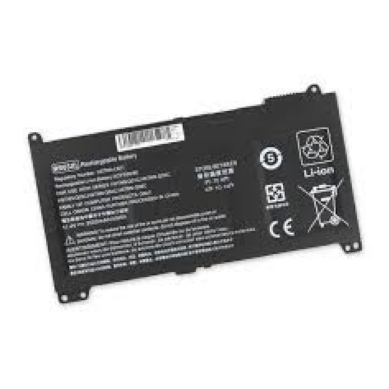

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [38]:
from PIL import Image
import numpy as np

IMG_SIZE = 300

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32)

    image = image / 255.0

    image = np.expand_dims(image, axis=0)

    prediction = cnn_model.predict(image, verbose=0)[0]

    top5 = prediction.argsort()[-5:][::-1]

    print("="*50)
    print("Top 5 Predictions")
    print("="*50)

    for idx in top5:
        print(f"{class_names[idx]:15s} : {prediction[idx]*100:.2f}%")

    class_index = np.argmax(prediction)

    confidence = float(prediction[class_index])

    predicted_class = class_names[class_index]

    return predicted_class, confidence

In [41]:
image_path = "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/metal/metal_1.jpg"

predict_image(image_path)

Top 5 Predictions
plastic         : 12.05%
glass           : 11.96%
clothes         : 11.43%
cardboard       : 10.71%
metal           : 10.38%


('plastic', 0.12048501521348953)

In [42]:
print(CNN_MODEL_PATH)

import os
print(os.path.exists(CNN_MODEL_PATH))

/content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_model.keras
True


In [43]:
cnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,172,047 (50.25 MB)

 Trainable params: 795,146 (3.03 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

 Optimizer params: 1,590,294 (6.07 MB)

In [44]:
CNN_MODEL_PATH = "/content/drive/MyDrive/VoiceVision-AI/03_Trained_Models/best_mobilenetv2.keras"

In [48]:
from tensorflow.keras.models import load_model

cnn_model = load_model(CNN_MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [49]:
predicted_class, confidence = predict_image(image_path)

print("Prediction:", predicted_class)
print("Confidence:", confidence * 100)

Prediction: metal
Confidence: 99.79514479637146


In [51]:
image_path = "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/plastic/plastic_1.jpg"

questions = [

    "Can I recycle this?",

    "Where should I throw this?",

    "Can I reuse this?",

    "What material is this made of?",

    "How long does it take to decompose?",

    "Is it harmful to the environment?"

]

for question in questions:

    print("\n" + "="*80)

    print("Question :", question)

    voicevision_pipeline(image_path, question)


Question : Can I recycle this?
VOICEVISION AI
Detected Item      : Plastic
Confidence         : 96.83%
Intent             : Recycling
Recyclable         : True
Recommended Bin    : Blue Recycling Bin

Recommendation
Plastic recyclability depends on the resin type, which is indicated by the recycling symbol number on the item. Containers should be emptied, rinsed, and sorted according to local recycling guidelines before collection. Certain plastics, such as PET and HDPE, are widely recyclable, while others like PVC or mixed plastics are often not accepted in standard programs.

Material
Plastic is a synthetic polymer derived primarily from petroleum or natural gas through chemical processing. It is generally non-biodegradable, though recyclability varies depending on the specific polymer type. Recycled plastic can be reprocessed into new products, though quality often degrades with repeated recycling cycles.

Environmental Impact
Improperly discarded plastic waste poses severe threats

In [52]:
tests = [

    (
        "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/plastic/plastic_1.jpg",
        "Can I recycle this?"
    ),

    (
        "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/metal/metal_1.jpg",
        "Where should I throw this?"
    ),

    (
        "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/paper/paper_1.jpg",
        "Can I reuse this?"
    ),

    (
        "/content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/cardboard/cardboard_1.jpg",
        "How long does it take to decompose?"
    )

]

for image_path, question in tests:

    print("\n" + "="*100)

    print("Image :", image_path)

    print("Question :", question)

    voicevision_pipeline(image_path, question)


Image : /content/drive/MyDrive/VoiceVision-AI/01_Datasets/Waste_Images/Dataset/plastic/plastic_1.jpg
Question : Can I recycle this?
VOICEVISION AI
Detected Item      : Plastic
Confidence         : 96.83%
Intent             : Recycling
Recyclable         : True
Recommended Bin    : Blue Recycling Bin

Recommendation
Plastic recyclability depends on the resin type, which is indicated by the recycling symbol number on the item. Containers should be emptied, rinsed, and sorted according to local recycling guidelines before collection. Certain plastics, such as PET and HDPE, are widely recyclable, while others like PVC or mixed plastics are often not accepted in standard programs.

Material
Plastic is a synthetic polymer derived primarily from petroleum or natural gas through chemical processing. It is generally non-biodegradable, though recyclability varies depending on the specific polymer type. Recycled plastic can be reprocessed into new products, though quality often degrades with rep

In [53]:
result = generate_response(image_path, question)

output_path = "/content/drive/MyDrive/VoiceVision-AI/05_Results/response.txt"

with open(output_path, "w") as f:

    for key, value in result.items():

        if isinstance(value, list):

            f.write(f"{key}:\n")

            for item in value:

                f.write(f" - {item}\n")

        else:

            f.write(f"{key}: {value}\n")

print("Response saved successfully!")
print(output_path)

Response saved successfully!
/content/drive/MyDrive/VoiceVision-AI/05_Results/response.txt


In [54]:
import json

result = generate_response(image_path, question)

print(json.dumps(result, indent=4))

{
    "Status": "Success",
    "Detected Item": "Cardboard",
    "Confidence": 99.99,
    "Intent": "Decomposition",
    "Recyclable": true,
    "Recommended Bin": "Blue Recycling Bin",
    "Response": "Cardboard is biodegradable and typically decomposes within two months under normal environmental conditions. In landfill environments with limited oxygen, decomposition can take longer and generate methane. Composting cardboard in shredded form accelerates the breakdown process.",
    "Material": "Cardboard is made from layers of paper pulp derived from wood fibers, often including recycled paper content. It is both biodegradable and recyclable, making it one of the more environmentally favorable packaging materials. Repeated recycling does gradually shorten the fiber length, limiting the number of recycling cycles.",
    "Environmental Impact": "Discarded cardboard that ends up in landfills breaks down slowly and contributes to methane emissions during anaerobic decomposition. Recyclin

In [55]:
print("="*80)
print("VoiceVision AI - Response Generator Completed Successfully")
print("="*80)

print("\nModules Integrated")

print("✓ Waste Classification (MobileNetV2)")
print("✓ Intent Detection (DistilBERT)")
print("✓ Knowledge Base")
print("✓ AI Response Generator")

print("\nProject is Ready for FastAPI Integration.")

VoiceVision AI - Response Generator Completed Successfully

Modules Integrated
✓ Waste Classification (MobileNetV2)
✓ Intent Detection (DistilBERT)
✓ Knowledge Base
✓ AI Response Generator

Project is Ready for FastAPI Integration.
